Charlie Frank

# Homework 3

This Notebook builds on the unit commitment model introduced in [Notebook 5](https://github.com/east-winds/power-systems-optimization/tree/master/Notebooks) and the storage model introduced in [Notebook 2](https://github.com/east-winds/power-systems-optimization/tree/master/Notebooks).

First, load (or install if necessary) a set of packages you'll need for this assignment...

In [1]:
# Uncomment and run this first line if you need to install or update packages
#import Pkg; Pkg.add("JuMP"); Pkg.add("HiGHS"); Pkg.add("DataFrames"); Pkg.add("CSV"); Pkg.add("Plots"); Pkg.add("VegaLite")
using JuMP
using HiGHS
using DataFrames
using CSV
using Plots; plotly();
using VegaLite  # to make some nice plots

#=
Function to convert JuMP outputs (technically, AxisArrays) with two-indexes to a dataframe
Inputs:
    var -- JuMP AxisArray (e.g., value.(GEN))
Reference: https://jump.dev/JuMP.jl/v0.19/containers/
=#
function value_to_df_2dim(var)
    solution = DataFrame(var.data, :auto)
    ax1 = var.axes[1]
    ax2 = var.axes[2]
    cols = names(solution)
    insertcols!(solution, 1, :r_id => ax1)
    solution = stack(solution, Not(:r_id), variable_name=:hour)
    solution.hour = foldl(replace, [cols[i] => ax2[i] for i in 1:length(ax2)], init=solution.hour)
    rename!(solution, :value => :gen)
    solution.hour = convert.(Int64,solution.hour)
    return solution
end

┌ Warning: Failed to load integration with PlotlyBase & PlotlyKaleido.
│   exception =
│    ArgumentError: Package PlotlyBase not found in current path.
│    - Run `import Pkg; Pkg.add("PlotlyBase")` to install the PlotlyBase package.
│    Stacktrace:
│      [1] macro expansion
│        @ .\loading.jl:2403 [inlined]
│      [2] macro expansion
│        @ .\lock.jl:376 [inlined]
│      [3] __require(into::Module, mod::Symbol)
│        @ Base .\loading.jl:2386
│      [4] require(into::Module, mod::Symbol)
│        @ Base .\loading.jl:2362
│      [5] top-level scope
│        @ C:\Users\bison\.julia\packages\Plots\GIume\src\backends.jl:581
│      [6] eval(m::Module, e::Any)
│        @ Core .\boot.jl:489
│      [7] _initialize_backend(pkg::Plots.PlotlyBackend)
│        @ Plots C:\Users\bison\.julia\packages\Plots\GIume\src\backends.jl:580
│      [8] backend(pkg::Plots.PlotlyBackend)
│        @ Plots C:\Users\bison\.julia\packages\Plots\GIume\src\backends.jl:256
│      [9] plotly()
│        @

value_to_df_2dim (generic function with 1 method)

## Question 1 - Compare startup costs in unit commitment

**A. Code and run basic model.**

Data for this problem is stored in [`Homeworks/hw3_data`](hw3_data/).

Following the `unit_commitment_simple` modeling formulation in [Notebook 5](https://github.com/east-winds/power-systems-optimization/tree/master/Notebooks), load the above data and create a unit commitment solver function with the following set of constraints:

- Demand balance
- Minimum / maximum generator constraints (non-committed)
- Minimum / maximum generator constraints (committed)
- Three-variable commitment formulation

Note: the data (with hours 1-24) is already in local time. Hence, do not convert from GMT to GMT-8.

Run the UC for the given day and plot a stacked area chart of generation using `@vlplot` from the `VegaLite` package.

Throughout this assignment, please use a relative MIP gap of 1% for all questions. (If you are having difficulty getting this to solve on your computer in a reasonble amount of time, you can relax the gap but please then specify clearly in your comments that you have done so.)

In [2]:
# Load Data 
gen_info = DataFrame(CSV.File("hw3_data/Generators_data.csv"))
fuels = DataFrame(CSV.File("hw3_data/Fuels_data.csv"))
loads = DataFrame(CSV.File("hw3_data/Demand.csv"))
gen_variable = DataFrame(CSV.File("hw3_data/Generators_variability.csv"))
# make column names lowercase
for f in [gen_info, fuels, loads, gen_variable]
    rename!(f, lowercase.(names(f)))
end

In [3]:
# Construct generator dataframe 
# columns for our column only
select!(gen_info, 1:26)

# Join generator info with fuel costs
gen_df = outerjoin(gen_info, fuels, on = :fuel)
rename!(gen_df, :cost_per_mmbtu => :fuel_cost)
gen_df.fuel_cost[ismissing.(gen_df[:, :fuel_cost])] .= 0 # missing fuel costs to 0

# Flag variable generators
gen_df[!, :is_variable] .= false
gen_df[in(["onshore_wind_turbine", "small_hydroelectric",
           "solar_photovoltaic"]).(gen_df.resource), :is_variable] .= true

# full name of gen
# format: "<region>_<resource>_<cluster>.0"
gen_df.gen_full = lowercase.(gen_df.region .* "_" .* gen_df.resource .* "_" .*
                              string.(gen_df.cluster) .* ".0")

# remove no cap gens 
gen_df = gen_df[gen_df.existing_cap_mw .> 0, :]

# mod variable format 
gen_variable_long = stack(gen_variable,
                          Not(:hour),
                          variable_name = :gen_full,
                          value_name    = :cf)


Row,hour,gen_full,cf
,Int64,String,Float64
1,1,wec_sdge_biomass_1.0,1.0
2,2,wec_sdge_biomass_1.0,1.0
3,3,wec_sdge_biomass_1.0,1.0
4,4,wec_sdge_biomass_1.0,1.0
5,5,wec_sdge_biomass_1.0,1.0
6,6,wec_sdge_biomass_1.0,1.0
7,7,wec_sdge_biomass_1.0,1.0
8,8,wec_sdge_biomass_1.0,1.0
9,9,wec_sdge_biomass_1.0,1.0


In [4]:
function unit_commitment_simple(gen_df, loads, gen_variable, mip_gap)
    UC = Model(HiGHS.Optimizer)
    set_optimizer_attribute(UC, "mip_rel_gap", mip_gap)

    # Sets
    G_thermal    = gen_df[gen_df[!, :up_time] .> 0, :r_id]  # thermal
    G_nonthermal = gen_df[gen_df[!, :up_time] .== 0, :r_id]  # non thermal
    G_var        = gen_df[gen_df[!, :is_variable] .== 1, :r_id]  # var renewables
    G_nonvar     = gen_df[gen_df[!, :is_variable] .== 0, :r_id]  # dispatch
    G_nt_nonvar  = intersect(G_nonvar, G_nonthermal)              # dispatch non thermal
    G            = gen_df.r_id                                    # all gen
    T            = loads.hour                                     # all time periods
    T_red        = loads.hour[1:end-1]                            # all except last hour

    # Capacity factors for variable generators timeseries
    gen_var_cf = innerjoin(gen_variable,
                     gen_df[gen_df.is_variable .== 1,
                            [:r_id, :gen_full, :existing_cap_mw]],
                     on = :gen_full)

    # Decision variables
    @variables(UC, begin
        GEN[G, T] >= 0 # generation output (MW)
        COMMIT[G_thermal, T], Bin  # commitment status
        START[G_thermal, T], Bin # start up decision
        SHUT[G_thermal, T], Bin # shut down decision
    end)

    # Objective: minimize var + start up costs
    @objective(UC, Min,
        # Dispatch nonvar: heat rate × fuel cost + VOM
        sum((gen_df[gen_df.r_id .== i, :heat_rate_mmbtu_per_mwh][1] * gen_df[gen_df.r_id .== i, :fuel_cost][1] +
             gen_df[gen_df.r_id .== i, :var_om_cost_per_mwh][1]) * GEN[i, t]
            for i in G_nonvar for t in T) +
        # Variable renewables: VOM only
        sum(gen_df[gen_df.r_id .== i, :var_om_cost_per_mwh][1] * GEN[i, t]
            for i in G_var for t in T) +
        # Start up costs: cost/MW × capacity × START binary
        sum(gen_df[gen_df.r_id .== i, :start_cost_per_mw][1] *
            gen_df[gen_df.r_id .== i, :existing_cap_mw][1] *
            START[i, t]
            for i in G_thermal for t in T)
    )

    # Demand balance
    @constraint(UC, cDemand[t in T],
        sum(GEN[i, t] for i in G) == loads[loads.hour .== t, :demand][1])

    # Non committed generators
    # Dispatchable non-thermal: bound capacity
    @constraint(UC, Cap_nt_nonvar[i in G_nt_nonvar, t in T],
        GEN[i, t] <= gen_df[gen_df.r_id .== i, :existing_cap_mw][1])
    # Variable renewables: bound capacity factor × capacity
    @constraint(UC, Cap_var[i in 1:nrow(gen_var_cf)],
        GEN[gen_var_cf[i, :r_id], gen_var_cf[i, :hour]] <=
            gen_var_cf[i, :cf] * gen_var_cf[i, :existing_cap_mw])

    # Committed therm gen        
    # Min output: min power fraction × capacity
    @constraint(UC, Cap_thermal_min[i in G_thermal, t in T],
        GEN[i, t] >= COMMIT[i, t] *
                     gen_df[gen_df.r_id .== i, :existing_cap_mw][1] *
                     gen_df[gen_df.r_id .== i, :min_power][1])
    # Max output: full capacity
    @constraint(UC, Cap_thermal_max[i in G_thermal, t in T],
        GEN[i, t] <= COMMIT[i, t] *
                     gen_df[gen_df.r_id .== i, :existing_cap_mw][1])

    # Unit commitment constraints
    #  Minimum up time
    @constraint(UC, Startup[i in G_thermal, t in T],
        COMMIT[i, t] >= sum(START[i, tt]
                            for tt in intersect(T,
                                (t - gen_df[gen_df.r_id .== i, :up_time][1]):t)))

    # Minimum down time
    @constraint(UC, Shutdown[i in G_thermal, t in T],
        1 - COMMIT[i, t] >= sum(SHUT[i, tt]
                                for tt in intersect(T,
                                    (t - gen_df[gen_df.r_id .== i, :down_time][1]):t)))

    # Commitment state                                
    @constraint(UC, CommitmentStatus[i in G_thermal, t in T_red],
        COMMIT[i, t+1] - COMMIT[i, t] == START[i, t+1] - SHUT[i, t+1])

    # Solve
    optimize!(UC)

    # extract results
    gen    = value_to_df_2dim(value.(GEN))
    commit = value_to_df_2dim(value.(COMMIT))

    # Curtailment
    curtail = innerjoin(gen_var_cf, gen, on = [:r_id, :hour])
    curtail.curt = curtail.cf .* curtail.existing_cap_mw .- curtail.gen

    return (
        gen    = gen,
        commit = commit,
        curtail = curtail,
        cost   = objective_value(UC),
        status = termination_status(UC)
    )
end

unit_commitment_simple (generic function with 1 method)

Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 2167 rows; 1752 cols; 6858 nonzeros; 1224 integer variables (1224 binary)
Coefficient ranges:
  Matrix  [1e+00, 6e+02]
  Cost    [5e+00, 5e+04]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 2e+03]
Presolving model
2013 rows, 1707 cols, 6595 nonzeros  0s
1791 rows, 1423 cols, 7349 nonzeros  0s
Presolve reductions: rows 1791(-376); columns 1423(-329); nonzeros 7349(+491) 

Solving MIP model with:
   1791 rows
   1423 cols (968 binary, 0 integer, 0 implied int., 455 continuous, 0 domain fixed)
   7349 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper

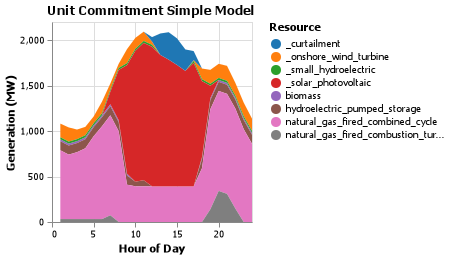

In [17]:
# Run model
T_period = loads.hour
solution = unit_commitment_simple(gen_df, loads, gen_variable_long, 0.01) # 0.01 mip gap

println("Status: ", solution.status)
println("Total cost: ", round(solution.cost, digits=2))

# prep plotting
sol_gen = innerjoin(solution.gen,
                    gen_df[!, [:r_id, :resource]],
                    on = :r_id)

# combine by resource and hour
sol_gen = combine(groupby(sol_gen, [:resource, :hour]), :gen => sum)

# rename gens 
sol_gen[sol_gen.resource .== "solar_photovoltaic",   :resource] .= "_solar_photovoltaic"
sol_gen[sol_gen.resource .== "onshore_wind_turbine", :resource] .= "_onshore_wind_turbine"
sol_gen[sol_gen.resource .== "small_hydroelectric",  :resource] .= "_small_hydroelectric"


# add curtailment
curtail_add = combine(groupby(solution.curtail, [:hour]), :curt => sum)
curtail_add[!, :resource] .= "_curtailment"
rename!(curtail_add, :curt_sum => :gen_sum)
append!(sol_gen, curtail_add[:, [:resource, :hour, :gen_sum]])

# stacked area chart 
sol_gen |>
@vlplot(:area,
    x = {:hour, title = "Hour of Day"},
    y = {:gen_sum, stack = :zero, title = "Generation (MW)"},
    color = {"resource:n", scale = {scheme = "category10"},
             title = "Resource"},
    title = "Unit Commitment Simple Model"
)

**B. Zero startup costs sensitivity**

Next, create a modified version of the generator dataframe (`gen_df_sens = copy(gen_df)`) and set the startup costs for all generators to be 0.

Rerun the UC and compare with the first solution. What are the main differences and why?

Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 2167 rows; 1752 cols; 6858 nonzeros; 1224 integer variables (1224 binary)
Coefficient ranges:
  Matrix  [1e+00, 6e+02]
  Cost    [5e+00, 5e+01]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 2e+03]
Presolving model
2013 rows, 1707 cols, 6595 nonzeros  0s
1791 rows, 1423 cols, 7349 nonzeros  0s
Presolve reductions: rows 1791(-376); columns 1423(-329); nonzeros 7349(+491) 

Solving MIP model with:
   1791 rows
   1423 cols (968 binary, 0 integer, 0 implied int., 455 continuous, 0 domain fixed)
   7349 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper

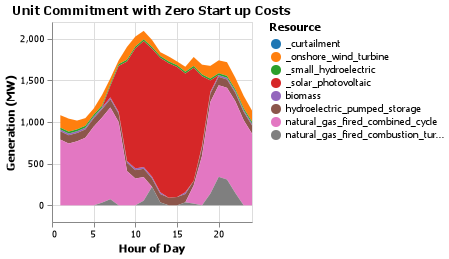

In [8]:
# copy generator dataframe and 0 start up costs
gen_df_sens = copy(gen_df)
gen_df_sens[!, :start_cost_per_mw] .= 0.0

# Run with mods
solution_sens = unit_commitment_simple(gen_df_sens, loads, gen_variable_long, 0.01)

# prep plotting
sol_gen_sens = innerjoin(solution_sens.gen,
                    gen_df_sens[!, [:r_id, :resource]],
                    on = :r_id)
sol_gen_sens = combine(groupby(sol_gen_sens, [:resource, :hour]), :gen => sum)

sol_gen_sens[sol_gen_sens.resource .== "solar_photovoltaic", :resource] .= "_solar_photovoltaic"
sol_gen_sens[sol_gen_sens.resource .== "onshore_wind_turbine", :resource] .= "_onshore_wind_turbine"
sol_gen_sens[sol_gen_sens.resource .== "small_hydroelectric", :resource] .= "_small_hydroelectric"

curtail_add = combine(groupby(solution_sens.curtail, [:hour]), :curt => sum)
curtail_add[!, :resource] .= "_curtailment"
rename!(curtail_add, :curt_sum => :gen_sum)
append!(sol_gen_sens, curtail_add[:, [:resource, :hour, :gen_sum]])

# 
sol_gen_sens |>
@vlplot(
    :area,
    x = {:hour, title = "Hour of Day"},
    y = {:gen_sum, stack = :zero, title = "Generation (MW)"},
    color = {"resource:n", scale = {scheme = "category10"}, title = "Resource"},
    title = "Unit Commitment with Zero Start up Costs"
)

In [ ]:
println("\nBaseline Solution")
println("Status: ", solution.status)
println("Total cost: ", round(solution.cost, digits=2))

println("\n0 Start up solution")
println("Status: ", solution_sens.status)
println("Total cost: ", round(solution_sens.cost, digits=2))

println("Difference of Cost (0 start - base): ", round(solution_sens.cost - solution.cost, digits=2))


Baseline Solution
Status: OPTIMAL
Total cost: 473965.78

0 Start up solution
Status: OPTIMAL
Total cost: 395637.97
Difference of Cost (0 start - base): -78327.81


The primary differences in the baseline case and the zero start up cost scenario is the total cost for each and the amount of curtailment. The zero start up cost scenario costs $78,327.81 less than the baseline case, since as the scenario title suggests, there are no start up costs, eliminating a decent part of the cost function. Secondly is the elimination of curtailmen. Since start up costs are zero there is no harm to shutting off a generator. So, as the days renewables increase, it is not more cost efficient to leave thermal generators on that would result in curtailment. Instead they are simply turned off until they are needed again. This does generally very few changes to the makeup of energy generation throughout the day but some periods, particularly from ~10am to 3pm, see major modifications due to solar being able to primarily fill the demand. Since start up costs are 0 we see combined cycle plants completely shut off in this period instead of staying on to avoid start up costs in the baseline. 

## Question 2: Implement pumped hydropower storage

In the data, we have a generator `hydroelectric_pumped_storage` which is a pumped hydro storage (PHS) facility. We have been treating it as a free resource, but in fact, it's a battery. 

The PHS equations for stored water are identical to the state of charge for the battery in Notebook 2:

\begin{align*} 
SOC_t = SOC_{t-1} + \big(CHARGE_t * battery\_eff - \frac{DISCHARGE_t}{battery\_eff}\big)  \quad \forall t \in T
\end{align*}

In addition, the PHS has a power capacity constraint given in the dataframe's `existing_cap_mw` variable. You will also need to implement an energy capacity constraint. 

**A. Code pumped hydropower storage constraints.**

Copy the `unit_commitment_simple` code above into a new cell below and rename the function `unit_commitment_storage`.

Reviewing [Notebook 2](https://github.com/east-winds/power-systems-optimization/tree/master/Notebooks), add in relevant constraints for charging and discharging pumped hydropower. Assume the following parameters:

- One-way efficiency is $battery_{eff} = 0.84$ (i.e., round-trip efficiency = $0.7$)
- Energy capacity = 4 x Power capacity
- Stored energy starts and ends the day at 50% capacity (you will need to code these constraints)

Indicate which equations and variables you have added and explain your steps using inline code comments (e.g. `# Comment`).

In [9]:
# New function w/ hydro storage
function unit_commitment_storage(gen_df, loads, gen_variable, mip_gap)
    UC = Model(HiGHS.Optimizer)
    set_optimizer_attribute(UC, "mip_rel_gap", mip_gap)

    # Sets
    G_thermal    = gen_df[gen_df[!, :up_time] .> 0, :r_id]  # thermal
    G_nonthermal = gen_df[gen_df[!, :up_time] .== 0, :r_id]  # non thermal
    G_var        = gen_df[gen_df[!, :is_variable] .== 1, :r_id]  # var renewables
    G_nonvar     = gen_df[gen_df[!, :is_variable] .== 0, :r_id]  # dispatch
    G_nt_nonvar  = intersect(G_nonvar, G_nonthermal)              # dispatch non thermal
    G            = gen_df.r_id                                    # all gen
    T            = loads.hour                                     # all time periods
    T_red        = loads.hour[1:end-1]                            # all except last hour
    G_phs = gen_df[gen_df.resource .== "hydroelectric_pumped_storage", :r_id] # NEW: pump hydro addition
    G_nt_nonvar_no_phs = setdiff(G_nt_nonvar, G_phs) # NEW: remove from nt_nonvar to add constraints provided

    # NEW: Pump hydro parameters
    battery_eff = 0.84   # one-way efficiency
    phs_power_cap = gen_df[gen_df.resource .== "hydroelectric_pumped_storage", # power capacity MWh
                           :existing_cap_mw][1]
    phs_energy_cap = 4.0 * phs_power_cap #Energy capacity 
    phs_soc_init = 0.5 * phs_energy_cap # Initial and final SOC = 50% of cap MWh

    # Capacity factors for variable generators timeseries
    gen_var_cf = innerjoin(gen_variable,
                     gen_df[gen_df.is_variable .== 1,
                            [:r_id, :gen_full, :existing_cap_mw]],
                     on = :gen_full)

    # Decision variables
    @variables(UC, begin
        GEN[G, T] >= 0               # generation output (MW)
        COMMIT[G_thermal, T], Bin    # commitment status
        START[G_thermal, T], Bin    # start up decision
        SHUT[G_thermal, T], Bin    # shut down decision
        CHARGE[G_phs, T] >= 0        # NEW:Pump hydro charge (MW)
        SOC[G_phs, T] >= 0           # NEW: State of charge (MWh)
    end)

    # Objective: minimize var + start up costs
    @objective(UC, Min,
        # Dispatch nonvar: heat rate × fuel cost + VOM
        sum((gen_df[gen_df.r_id .== i, :heat_rate_mmbtu_per_mwh][1] * gen_df[gen_df.r_id .== i, :fuel_cost][1] +
             gen_df[gen_df.r_id .== i, :var_om_cost_per_mwh][1]) * GEN[i, t]
            for i in G_nonvar for t in T) +
        # Variable renewables: VOM only
        sum(gen_df[gen_df.r_id .== i, :var_om_cost_per_mwh][1] * GEN[i, t]
            for i in G_var for t in T) +
        # Start up costs: cost/MW × capacity × START binary
        sum(gen_df[gen_df.r_id .== i, :start_cost_per_mw][1] *
            gen_df[gen_df.r_id .== i, :existing_cap_mw][1] *
            START[i, t]
            for i in G_thermal for t in T)
    )

    # Demand balance
    @constraint(UC, cDemand[t in T],
        sum(GEN[i, t] for i in G) - sum(CHARGE[i, t] for i in G_phs) == # NEW: add charge that is PHS load consumption for charging 
            loads[loads.hour .== t, :demand][1])

    # Non committed generators
    # Dispatchable non-thermal: bound capacity
    @constraint(UC, Cap_nt_nonvar[i in G_nt_nonvar, t in T],
        GEN[i, t] <= gen_df[gen_df.r_id .== i, :existing_cap_mw][1])
    # Variable renewables: bound capacity factor × capacity
    @constraint(UC, Cap_var[i in 1:nrow(gen_var_cf)],
        GEN[gen_var_cf[i, :r_id], gen_var_cf[i, :hour]] <=
            gen_var_cf[i, :cf] * gen_var_cf[i, :existing_cap_mw])

    # Committed therm gen        
    # Min output: min power fraction × capacity
    @constraint(UC, Cap_thermal_min[i in G_thermal, t in T],
        GEN[i, t] >= COMMIT[i, t] *
                     gen_df[gen_df.r_id .== i, :existing_cap_mw][1] *
                     gen_df[gen_df.r_id .== i, :min_power][1])
    # Max output: full capacity
    @constraint(UC, Cap_thermal_max[i in G_thermal, t in T],
        GEN[i, t] <= COMMIT[i, t] *
                     gen_df[gen_df.r_id .== i, :existing_cap_mw][1])

    # Unit commitment constraints
    #  Minimum up time
    @constraint(UC, Startup[i in G_thermal, t in T],
        COMMIT[i, t] >= sum(START[i, tt]
                            for tt in intersect(T,
                                (t - gen_df[gen_df.r_id .== i, :up_time][1]):t)))
    # Minimum down time
    @constraint(UC, Shutdown[i in G_thermal, t in T],
        1 - COMMIT[i, t] >= sum(SHUT[i, tt]
                                for tt in intersect(T,
                                    (t - gen_df[gen_df.r_id .== i, :down_time][1]):t)))

    # Commitment state                                
    @constraint(UC, CommitmentStatus[i in G_thermal, t in T_red],
        COMMIT[i, t+1] - COMMIT[i, t] == START[i, t+1] - SHUT[i, t+1])

    # NEW: Discharge cannot exceed power cap of pump hydro 
    @constraint(UC, PHS_discharge_cap[i in G_phs, t in T],
        GEN[i, t] <= phs_power_cap)
    # NEW: Charge power cannot exceed power capacity of pump hydro
    @constraint(UC, PHS_charge_cap[i in G_phs, t in T],
        CHARGE[i, t] <= phs_power_cap)

    # NEW: SOC cannot exceed the total energy capacity of pump hydro
    @constraint(UC, PHS_soc_max[i in G_phs, t in T],
        SOC[i, t] <= phs_energy_cap)
    # NEW: SOC cannot be negative
    @constraint(UC, PHS_soc[i in G_phs, t in T_red],
        SOC[i, t+1] == SOC[i, t] +
                       CHARGE[i, t+1] * battery_eff -
                       GEN[i, t+1] / battery_eff)

    # NEW: SOC at hour zero is inital value preset
    @constraint(UC, PHS_soc_start[i in G_phs],
        SOC[i, T[1]] == phs_soc_init +
                        CHARGE[i, T[1]] * battery_eff -
                        GEN[i, T[1]] / battery_eff)

    # NEW: SOC at final hour is preset 
    @constraint(UC, PHS_soc_end[i in G_phs],
        SOC[i, T[end]] == phs_soc_init)

    # Solve 
    optimize!(UC)

    # extract results
    gen    = value_to_df_2dim(value.(GEN))
    commit = value_to_df_2dim(value.(COMMIT))
    
    # curtailment
    curtail = innerjoin(gen_var_cf, gen, on = [:r_id, :hour])
    curtail.curt = curtail.cf .* curtail.existing_cap_mw .- curtail.gen

    # NEW: SOC and charge
    soc    = value_to_df_2dim(value.(SOC))
    charge = value_to_df_2dim(value.(CHARGE))

    return (
        gen     = gen,
        commit  = commit,
        curtail = curtail,
        soc     = soc, # NEW
        charge  = charge, # NEW
        cost    = objective_value(UC),
        status  = termination_status(UC)
    )
end

unit_commitment_storage (generic function with 1 method)

**B. Solve the new UC with PHS and plot.**

Using the above formulation, solve for the same parameters in Problem 1 and plot. For the purposes of plotting, you will want to create two resources&mdash;PHS_charge and PHS_discharge. By convention, you could put PHS_charge on top to indicate this is increasing system load.

Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 2264 rows; 1800 cols; 7050 nonzeros; 1224 integer variables (1224 binary)
Coefficient ranges:
  Matrix  [8e-01, 6e+02]
  Cost    [5e+00, 5e+04]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 2e+03]
Presolving model
2037 rows, 1754 cols, 6713 nonzeros  0s
1813 rows, 1493 cols, 7488 nonzeros  0s
Presolve reductions: rows 1813(-451); columns 1493(-307); nonzeros 7488(+438) 

Solving MIP model with:
   1813 rows
   1493 cols (968 binary, 0 integer, 0 implied int., 525 continuous, 0 domain fixed)
   7488 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper

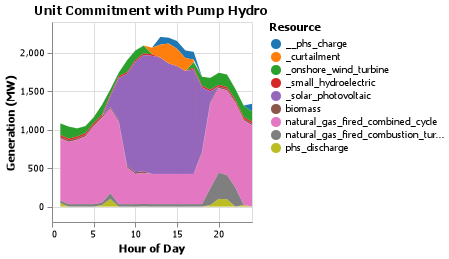

In [10]:
solution_storage = unit_commitment_storage(gen_df, loads, gen_variable_long, 0.01)

println("Status: ", solution_storage.status)
println("Total cost: ", round(solution_storage.cost, digits=2))

# prep plotting
sol_gen_storage = innerjoin(solution_storage.gen,
                            gen_df[!, [:r_id, :resource]],
                            on = :r_id)
# combine by resource and hour                            
sol_gen_storage = combine(groupby(sol_gen_storage, [:resource, :hour]), :gen => sum)

# rename gens
sol_gen_storage[sol_gen_storage.resource .== "solar_photovoltaic",   :resource] .= "_solar_photovoltaic"
sol_gen_storage[sol_gen_storage.resource .== "onshore_wind_turbine", :resource] .= "_onshore_wind_turbine"
sol_gen_storage[sol_gen_storage.resource .== "small_hydroelectric",  :resource] .= "_small_hydroelectric"
sol_gen_storage[sol_gen_storage.resource .== "hydroelectric_pumped_storage", :resource] .= "phs_discharge"

# pump hydro charge format ISSUE NOT ON TOP
phs_charge_plot = combine(groupby(solution_storage.charge, :hour), :gen => sum)
phs_charge_plot[!, :resource] .= "__phs_charge"
rename!(phs_charge_plot, :gen_sum => :gen_sum)
append!(sol_gen_storage, phs_charge_plot[:, [:resource, :hour, :gen_sum]])

# add curtailment
curtail_agg = combine(groupby(solution_storage.curtail, [:hour]), :curt => sum)
curtail_agg[!, :resource] .= "_curtailment"
rename!(curtail_agg, :curt_sum => :gen_sum)
append!(sol_gen_storage, curtail_agg[:, [:resource, :hour, :gen_sum]])

# stacked area chart
sol_gen_storage |>
@vlplot(
    :area,
    x = {:hour, title = "Hour of Day"},
    y = {:gen_sum, stack = :zero, title = "Generation (MW)"},
    color = {"resource:n", scale = {scheme = "category10"}, 
             title = "Resource"},
    title = "Unit Commitment with Pump Hydro"
)

**C. Interpret results**

Answer with a few sentences each of the following:

1. Compare your results to `unit_commitment_simple`. Have any commitments changed?

2. Interpret what is happening with the PHS facility during the day in terms of charging and discharging.

3. Has curtailment reduced? (Explain this in the context of the PHS operation.)

In [15]:
println("Total cost pump hydro: ", round(solution_storage.cost, digits=2))
println("Baseline cost: ", round(solution.cost, digits=2))
println("Curtailment with pump hydro: ", round(sum(solution_storage.curtail.curt), digits=2))
println("Curtailment baseline: ", round(sum(solution.curtail.curt), digits=2))
println("Difference of cost: ", round(solution_storage.cost - solution.cost, digits=2))
println("Difference of curtailment: ", round(sum(solution_storage.curtail.curt) - sum(solution.curtail.curt), digits=2))

phs_id = gen_df[gen_df.resource .== "hydroelectric_pumped_storage", :r_id][1]
phs_discharge = solution_storage.gen[solution_storage.gen.r_id .== phs_id,
                                     [:hour, :gen]]
phs_charge    = solution_storage.charge[solution_storage.charge.r_id .== phs_id,
                                        [:hour, :gen]]
phs_soc       = solution_storage.soc[solution_storage.soc.r_id .== phs_id,
                                     [:hour, :gen]]
rename!(phs_discharge, :gen => :discharge_mw)
rename!(phs_charge,    :gen => :charge_mw)
rename!(phs_soc,       :gen => :soc_mwh)

# Combine into one table for easy reading
phs_table = innerjoin(phs_discharge, phs_charge, on = :hour)
phs_table = innerjoin(phs_table,     phs_soc,    on = :hour)


Total cost pump hydro: 506572.09
Baseline cost: 473965.78
Curtailment with pump hydro: 931.34
Curtailment baseline: 1213.68
Difference of cost: 32606.31
Difference of curtailment: -282.34


Row,hour,discharge_mw,charge_mw,soc_mwh
,Int64,Float64,Float64,Float64
1,1,47.4628,0.0,143.497
2,2,0.0,0.0,143.497
3,3,0.0,0.0,143.497
4,4,0.0,0.0,143.497
5,5,0.0,0.0,143.497
6,6,20.5372,0.0,119.048
7,7,100.0,0.0,0.0
8,8,-0.0,0.0,-0.0
9,9,0.0,0.0,0.0


1. Yes, compared to Unit Commitment Simple, Unit commitment with pumped hydro storage changes some of the commitments. This change is primarily in the form of modification of the hydro electric storage from a free resource to a properly constrained battery with the additions it makes to generation varying across the entire 24 hours. Most other resources stay fairly similar, more gas combined cycle is needed near hours 22-23 to assist in meeting End of day SOC constraints for the battery. Combined Cycle Gas is the primary generator used to backfill the lost generation from the hydro electric modification in every other part of the day as well. The lost output was a fairly small share of the overall generation so we don't see much variation otherwise.

2. As a properly constrained battery, pumped hydro only discharges a couple of times during the day at the front and back end of the solar production window. (along with a small discharge in the middle of the day) Charging occurs primarily during periods of high curtailment through the early to mid afternoon. One single period of charging in the final hour of the day serves to get the battery to its End of day SOC of 50%. The optimal solution appears to be positioned at charging when it is cheapest, i.e. when there is free energy in the grid due to curtailmemt, and discharging at times of variation in the mix of generation. These discharges are to assist in the transition between easy free solar generation times and times requiring active generation primarily covered by combined cycle gas. 

3. Curtailment did reduce between the 2 scenarios. Pumped Hydro had less curtailment than the baseline case by nearly 300 MWh. Within the context of the operation, pumped hydro can charge from the curtailment in the middle part of the day and absorb energy that otherwise would have been wasted, thus reducing curtailment by increasing consumption via charging. 

## Question 3: LLM Exercise
Now, let us explore exactly how much pumped hydropower storage would be needed to completely
eliminate the need for fossil fuels in this system. First, we need to increase solar capacity to ensure
there is enough energy on the system. Use 10,000 MW of solar for this problem. Next, use a
suitable LLM to explore this sensitivity. Create a new section at the end of your Homework 3
notebook titled “Question 3: LLM Exercise”. Include the LLM prompts used (as markdown text
cells in your notebook) and ensure all code is replicated in the notebook (i.e., do not have the LLM
run the code or perform any computation outside of the notebook).

a) Evaluate the capacity of pumped hydropower storage when gas generation (across all the
generators) reaches 0. Plot the gas generation vs pumped hydropower storage capacity.

b) Show solar curtailment percentage for the final system and plot dispatch. Does this seem
cost-effective for a 2 GW peak demand system?

I utilized Claude Sonnet 4.6 for this portion of the assignment, the free version 
I uploaded the HTML version of my code thus far to provide context for the assignment prompt was an attachment of the file with prompt:

**Utilize the attached file as a guideline for code generation for a project I am working on, using the file and my prompts I want you to generate code that achieves my goals**

I then uploaded the assignment prompt sans the LLM instructions since I already requested code generation prompt:

**Now, let us explore exactly how much pumped hydropower storage would be needed to completely
eliminate the need for fossil fuels in this system. First, we need to increase solar capacity to ensure
there is enough energy on the system. Use 10,000 MW of solar for this problem. 
a Evaluate the capacity of pumped hydropower storage when gas generation (across all the
generators) reaches 0. Plot the gas generation vs pumped hydropower storage capacity.
b Show solar curtailment percentage for the final system and plot dispatch. Does this seem
cost-effective for a 2 GW peak demand system?**

This produced the code you see below (2 plotting blocks and 1 solving block), the original formulation, with a single change made to the range for searching for the point when no gas is a part of the setup. Orginally it searched pumped hydro capacity from 100MW to 3000MW on a 100MW step, this did not find a no gas solution, so I prompted:

**Code did not plot a no gas solution, what changes can I make**

This resulted in a response suggested to change the step size to 200MW and searching range to 200MW to 5000MW, this found a solution at 4600MW, the code to confirm that in the block after those produced in the first run is shown at the bottom.

In [23]:
# =============================================================================
# SECTION 1: PHS Capacity Sweep — Eliminating Fossil Fuel Generation
# =============================================================================

# --- Set up sensitivity: 10,000 MW solar capacity ---
gen_df_solar = copy(gen_df)
gen_df_solar[gen_df_solar.resource .== "solar_photovoltaic", :existing_cap_mw] .= 10000.0

# Identify gas generator r_ids (any resource using natural gas fuel)
gas_ids = gen_df_solar[occursin.("naturalgas", gen_df_solar.resource) .|
                        occursin.("natural_gas", gen_df_solar.resource), :r_id]

# --- PHS capacity sweep ---
# We scale the PHS power capacity from its existing value up to a large multiple
# and track total gas generation at each step
phs_base_cap = gen_df[gen_df.resource .== "hydroelectric_pumped_storage",
                       :existing_cap_mw][1]  # baseline = 100 MW

# Sweep multipliers: test PHS power capacities from 100 MW up to 3000 MW
phs_capacities = collect(200:200:5000)

# Store results
results_sweep = DataFrame(
    phs_cap_mw       = Float64[],
    total_gas_mwh    = Float64[],
    total_cost       = Float64[],
    curtailment_mwh  = Float64[],
    status           = String[]
)

for cap in phs_capacities
    # Scale PHS capacity in the generator dataframe
    gen_df_sweep = copy(gen_df_solar)
    gen_df_sweep[gen_df_sweep.resource .== "hydroelectric_pumped_storage",
                 :existing_cap_mw] .= Float64(cap)

    # Solve UC with storage constraints
    sol = unit_commitment_storage(gen_df_sweep, loads, gen_variable_long, 0.01)

    # Total gas generation (MWh) across all gas generators in this solution
    gas_gen = sum(sol.gen[in.(sol.gen.r_id, Ref(gas_ids)), :gen])

    # Total curtailment (MWh)
    total_curt = sum(sol.curtail.curt)

    push!(results_sweep, (
        Float64(cap),
        gas_gen,
        sol.cost,
        total_curt,
        string(sol.status)
    ))

    println("PHS cap: $(cap) MW | Gas gen: $(round(gas_gen, digits=1)) MWh | ",
            "Curtailment: $(round(total_curt, digits=1)) MWh | Status: $(sol.status)")

    # Stop early once gas generation hits zero
    if gas_gen < 1.0
        println("\n>>> Gas generation eliminated at PHS capacity = $(cap) MW")
        break
    end
end


Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 2264 rows; 1800 cols; 7050 nonzeros; 1224 integer variables (1224 binary)
Coefficient ranges:
  Matrix  [8e-01, 6e+02]
  Cost    [5e+00, 5e+04]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 6e+03]
Presolving model
2037 rows, 1754 cols, 6713 nonzeros  0s
1813 rows, 1482 cols, 7477 nonzeros  0s
Presolve reductions: rows 1813(-451); columns 1482(-318); nonzeros 7477(+427) 

Solving MIP model with:
   1813 rows
   1482 cols (968 binary, 0 integer, 0 implied int., 514 continuous, 0 domain fixed)
   7477 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper

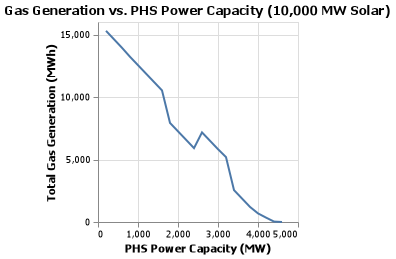

In [26]:
# =============================================================================
# PART A: Plot Gas Generation vs PHS Storage Capacity
# =============================================================================

results_sweep |>
@vlplot(
    :line,
    x = {:phs_cap_mw,    title = "PHS Power Capacity (MW)"},
    y = {:total_gas_mwh, title = "Total Gas Generation (MWh)"},
    title = "Gas Generation vs. PHS Power Capacity (10,000 MW Solar)"
)


Final PHS capacity (zero gas): 4600.0 MW
Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 2264 rows; 1800 cols; 7050 nonzeros; 1224 integer variables (1224 binary)
Coefficient ranges:
  Matrix  [8e-01, 6e+02]
  Cost    [5e+00, 5e+04]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 2e+04]
Presolving model
2037 rows, 1754 cols, 6713 nonzeros  0s
1813 rows, 1491 cols, 7486 nonzeros  0s
Presolve reductions: rows 1813(-451); columns 1491(-309); nonzeros 7486(+436) 

Solving MIP model with:
   1813 rows
   1491 cols (968 binary, 0 integer, 0 implied int., 523 continuous, 0 domain fixed)
   7486 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial low

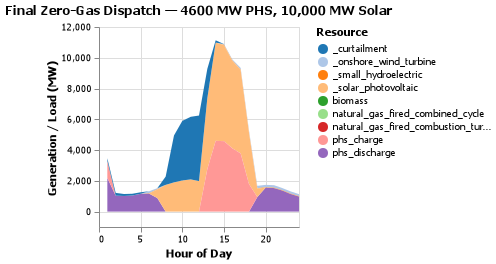

In [ ]:
# =============================================================================
# PART B: Final System — Curtailment and Dispatch at Zero-Gas PHS Capacity
# =============================================================================

# Use the PHS capacity at which gas first reaches zero
phs_final_cap = results_sweep[results_sweep.total_gas_mwh .< 1.0, :phs_cap_mw][1]
println("\nFinal PHS capacity (zero gas): $(phs_final_cap) MW")

# Re-run the model at the final PHS capacity to extract full dispatch detail
gen_df_final = copy(gen_df_solar)
gen_df_final[gen_df_final.resource .== "hydroelectric_pumped_storage",
             :existing_cap_mw] .= phs_final_cap

solution_final = unit_commitment_storage(gen_df_final, loads, gen_variable_long, 0.01)

# --- Curtailment statistics ---
total_solar_available = sum(
    gen_variable_long[gen_variable_long.gen_full .== "wec_sdge_solar_photovoltaic_1.0", :cf] .*
    10000.0)

total_curtailment = sum(solution_final.curtail.curt)
curtailment_pct   = round(100.0 * total_curtailment / total_solar_available, digits=2)

println("\n=== Part B: Final System Curtailment ===")
println("PHS power capacity          : $(phs_final_cap) MW")
println("PHS energy capacity         : $(4 * phs_final_cap) MWh")
println("Total solar available (MWh) : $(round(total_solar_available, digits=1))")
println("Total curtailment (MWh)     : $(round(total_curtailment,     digits=1))")
println("Solar curtailment %         : $(curtailment_pct)%")
println("Peak demand (MW)            : 2000  (system reference)")
println("Total cost (\$)              : $(round(solution_final.cost, digits=2))")

# --- Prepare dispatch for plotting ---
sol_gen_final = innerjoin(solution_final.gen,
                          gen_df_final[!, [:r_id, :resource]],
                          on = :r_id)
sol_gen_final = combine(groupby(sol_gen_final, [:resource, :hour]), :gen => sum)

sol_gen_final[sol_gen_final.resource .== "solar_photovoltaic",          :resource] .= "_solar_photovoltaic"
sol_gen_final[sol_gen_final.resource .== "onshore_wind_turbine",        :resource] .= "_onshore_wind_turbine"
sol_gen_final[sol_gen_final.resource .== "small_hydroelectric",         :resource] .= "_small_hydroelectric"
sol_gen_final[sol_gen_final.resource .== "hydroelectric_pumped_storage",:resource] .= "phs_discharge"

# PHS charge
phs_charge_final = combine(groupby(solution_final.charge, :hour), :gen => sum)
phs_charge_final[!, :resource] .= "phs_charge"
rename!(phs_charge_final, :gen_sum => :gen_sum)
append!(sol_gen_final, phs_charge_final[:, [:resource, :hour, :gen_sum]])

# Curtailment
curtail_final = combine(groupby(solution_final.curtail, :hour), :curt => sum)
curtail_final[!, :resource] .= "_curtailment"
rename!(curtail_final, :curt_sum => :gen_sum)
append!(sol_gen_final, curtail_final[:, [:resource, :hour, :gen_sum]])

# --- Dispatch plot ---
sol_gen_final |>
@vlplot(
    :area,
    x = {:hour,    title = "Hour of Day"},
    y = {:gen_sum, stack = :zero, title = "Generation / Load (MW)"},
    color = {"resource:n", scale = {scheme = "category20"}, title = "Resource"},
    title = "Final Zero-Gas Dispatch — $(Int(phs_final_cap)) MW PHS, 10,000 MW Solar"
)

B. Solar curtailment was calculated to be 31.09%. Dispatch shows a massive midday spike and a large amount of curtailment over that period. Solar curtailment would be higher if not for the charging of the massive pumped hydro storage deployment. The amount of overbuiding of solar required to generate enough power through the middle part of the day is likely to not be economically reasonable even with the zero fuel costs of solar and charging options for pumped hydro. 

In [ ]:
# --- Safely identify the final PHS capacity ---
zero_gas_rows = results_sweep[results_sweep.total_gas_mwh .< 1.0, :]

if nrow(zero_gas_rows) > 0
    phs_final_cap = zero_gas_rows.phs_cap_mw[1]
    println("Gas eliminated at PHS capacity = $(phs_final_cap) MW")
else
    # Gas was never fully eliminated — use the capacity with the lowest gas generation
    phs_final_cap = results_sweep[argmin(results_sweep.total_gas_mwh), :phs_cap_mw]
    min_gas       = minimum(results_sweep.total_gas_mwh)
    println("WARNING: Gas not fully eliminated in sweep.")
    println("Using lowest gas generation achieved: $(round(min_gas, digits=1)) MWh at $(phs_final_cap) MW PHS")
end

Gas eliminated at PHS capacity = 4600.0 MW
